# Exercises

<div class="alert alert-success" style = "border-radius:10px;border-width:3px;border-color:darkgreen;font-family:Verdana,sans-serif;font-size:16px;">
    
**EXERCISE 1: Climate Change and Sea Ice Extent**<p>

We want to answer the question: Has there been a decrease in the amount of ice in the last years?

For that we will use the sea ice extent measurements from the [National Snow & Ice Data Center](https://nsidc.org).<p>

We perform the following processing steps:

</li>
<ol>
<ul>
</ul>
<li> We must read and clean the data.
<li> To compute the tendency for a given interval of time (month), we need to normalize the data.
<li> This values can be plotted for the entire time series or for particular months. 
<li> We can compute the trend as a simple linear regression (OLS) and quantitatively evaluate it.
<li> We can also estimate the extent value for 2025.

</ol>
</div>

In [2]:
import os
os.getcwd()

'd:\\edu_laptop\\Ironhack_AI_&_DataScience\\Months3-5\\week18\\Tusday\\lab-dsai-regression-exercises\\your-code'

In [3]:
# Load the data and show the info and contents:
import pandas as pd
ice = pd.read_csv('../data/SeaIce.txt',delim_whitespace=True)
print('shape: {}'.format(ice.shape))
ice.head() 

shape: (424, 6)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_8668\3565392519.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  ice = pd.read_csv('../data/SeaIce.txt',delim_whitespace=True)


,year,mo,data_type,region,extent,area
0,1979,1,Goddard,N,15.54,12.33
1,1980,1,Goddard,N,14.96,11.85
2,1981,1,Goddard,N,15.03,11.82
3,1982,1,Goddard,N,15.26,12.11
4,1983,1,Goddard,N,15.10,11.92


To compute the anomaly for a given interval of time, we can compute the mean for that interval of time (using the period 1981 through 2010 for the mean extend), before data cleaning.

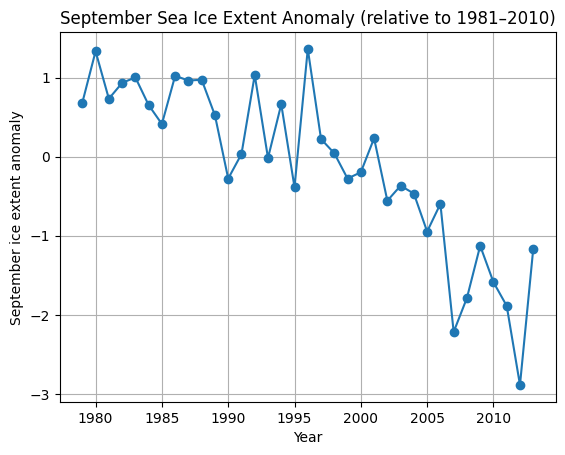

Trend slope: -0.089 million km² per year
p-value: 0.0000
Predicted September anomaly in 2025: -2.692 million km²


In [4]:
# Your code here
# Step 1: Extract year and month
ice['year'] = pd.to_datetime(ice['year'], format='%Y').dt.year  
# Alternatively, keep as integer.

# Step 2: Compute monthly means over 1981–2010
baseline = ice[(ice['year'] >= 1981) & (ice['year'] <= 2010)]
monthly_mean = baseline.groupby('mo')['extent'].mean().rename('mean_extent')

# Step 3: Merge and compute anomalies
ice = ice.merge(monthly_mean, on='mo')
ice['anomaly'] = ice['extent'] - ice['mean_extent']

# Step 4: Plot anomalies over time for a specific month (e.g., September)
import matplotlib.pyplot as plt
sept = ice[ice['mo'] == 9]
plt.plot(sept['year'], sept['anomaly'], marker='o')
plt.xlabel('Year'); plt.ylabel('September ice extent anomaly')
plt.title('September Sea Ice Extent Anomaly (relative to 1981–2010)')
plt.grid(True)
plt.show()

# Step 5: Fit linear trend using numpy.polyfit or stats.linregress
from scipy import stats
slope, intercept, r_value, p_value, std_err = stats.linregress(sept['year'], sept['anomaly'])
print(f"Trend slope: {slope:.3f} million km² per year")
print(f"p-value: {p_value:.4f}")

# Step 6: Predict for 2025
pred_2025 = intercept + slope * 2025
print(f"Predicted September anomaly in 2025: {pred_2025:.3f} million km²")

## Visualization

### The importance of plotting

Anscombe's quartet comprises four data sets that have nearly identical simple descriptive statistics, yet have very different distributions and appear very different when graphed. Each dataset consists of eleven (x,y) points. They were constructed in 1973 by the statistician Francis Anscombe to demonstrate both the importance of graphing data before analyzing it and the effect of outliers and other influential observations on statistical properties.

<center><img src="./images/Anscombe's_quartet_3.svg"  width="600"></center>

Source [Wikipedia](https://en.wikipedia.org/wiki/Anscombe%27s_quartet).



### Example 1: Housing Data

We'll continue with our Boston housing dataset

In [5]:
from pandas import read_csv
import pandas as pd
import matplotlib.pylab as plt


#Lets load the dataset and sample some
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
# Load data (space‑separated, no header)
df_boston = read_csv('../data/housing.csv', header=None, delimiter=r"\s+", names=column_names)
# Rename MEDV to PRICE for clarity
df_boston['PRICE'] = df_boston['MEDV']

### Histograms

Text(0, 0.5, 'count')

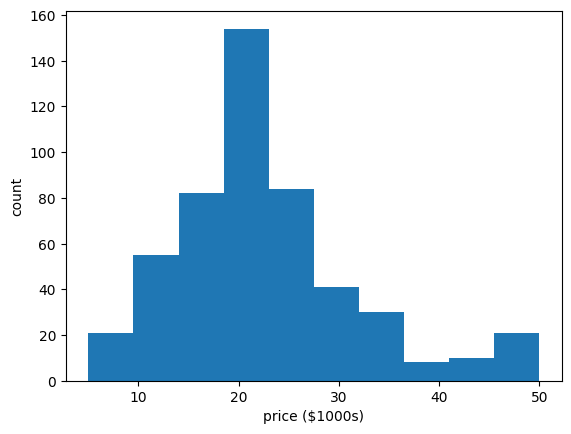

In [6]:
# Histogram of prices:
plt.hist(df_boston.PRICE) 
plt.xlabel('price ($1000s)')
plt.ylabel('count')

### Linear Regression Visualization: Seaborn lmplot

The ``lmplot()`` function from the Seaborn module is intended for exploring linear relationships of different forms in multidimensional datesets. Input data must be in a Pandas ``DataFrame``. To plot, provide the predictor and response variable names along with the dataset

We first consider the task of predicting median house values in the Boston area using as the predictor one of the attributes, for instance, LSTAT, defined as the "proportion of lower status of the population".
Seaborn visualization can be used to show this linear relationships easily:

We will use the variable price as our response $\textbf{y}$ and LSTAT as our predictor $\textbf{x}$.


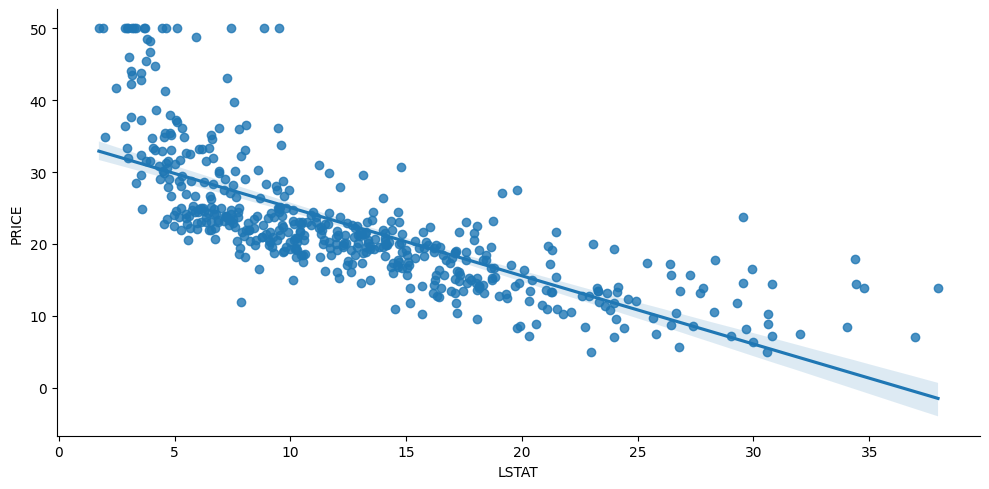

In [7]:
import seaborn as sns
# Visualization of the relations between price and LSTAT
sns.lmplot(x="LSTAT", y="PRICE", data=df_boston, aspect=2);

lmplot has two main components. 

+ The first is a scatterplot, showing the observed datapoints. 
+ The second is a regression line, showing the estimated linear model relating the two variables. Because the regression line is only an estimate, it is plotted with a 95% confidence band to give an impression of the certainty in the model (using Bootstraping).

Is the relationship between the house price and ``lstat`` non-linear? Is the straight line a poor fit? Maybe a better fit can be obtained by including higher order terms:

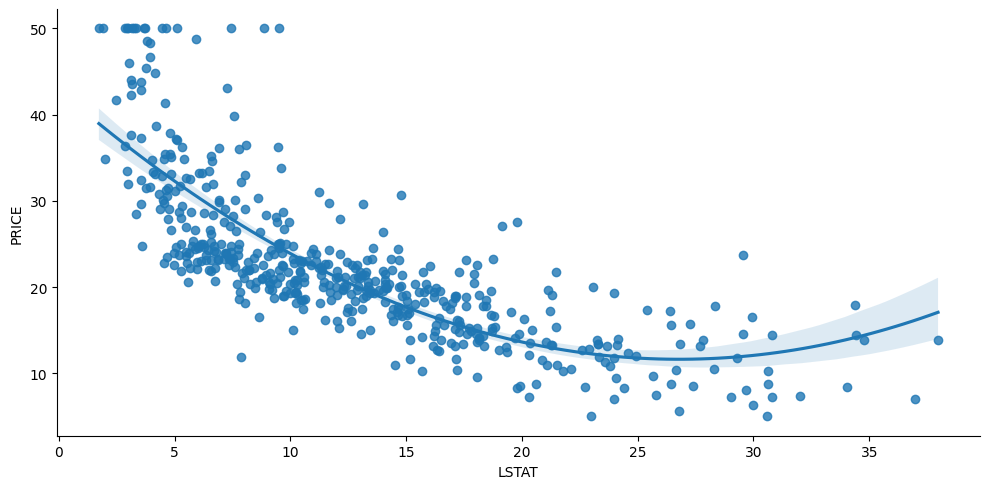

In [8]:
# Estimate a polynomial regression of order 2
sns.lmplot(x="LSTAT", y="PRICE", data=df_boston, aspect=2, order=2);

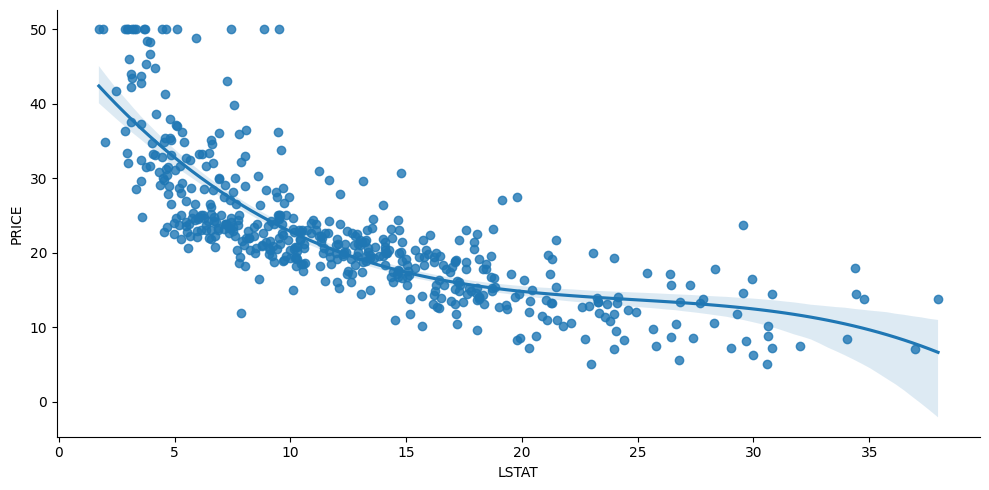

In [9]:
# Estimate a polynomial regression of order 3
sns.lmplot(x="LSTAT", y="PRICE", data=df_boston, aspect=2, order=3);


What if we consider variable RM or AGE?

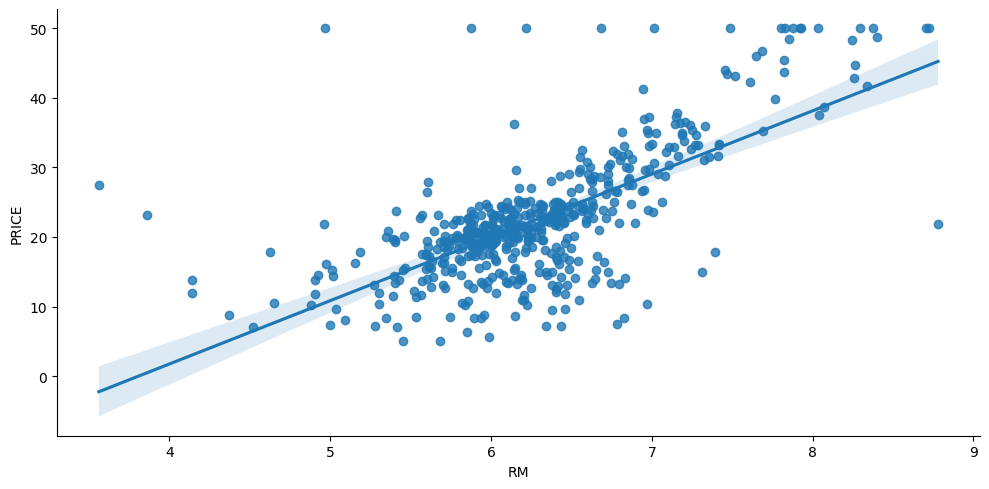

In [10]:
# Visualization of the relations between price and "average number of rooms per dwelling"
sns.lmplot(x="RM", y="PRICE", data=df_boston, aspect=2);

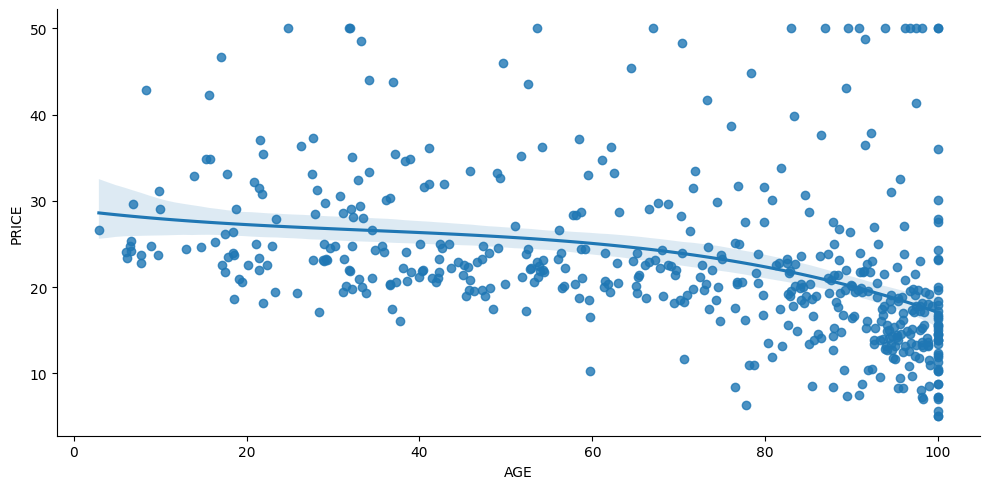

In [11]:
# Visualization of the relations between price and "proportion of owner-occupied units built prior to 1940"
sns.lmplot(x="AGE", y="PRICE", data=df_boston, aspect=2, order=3);

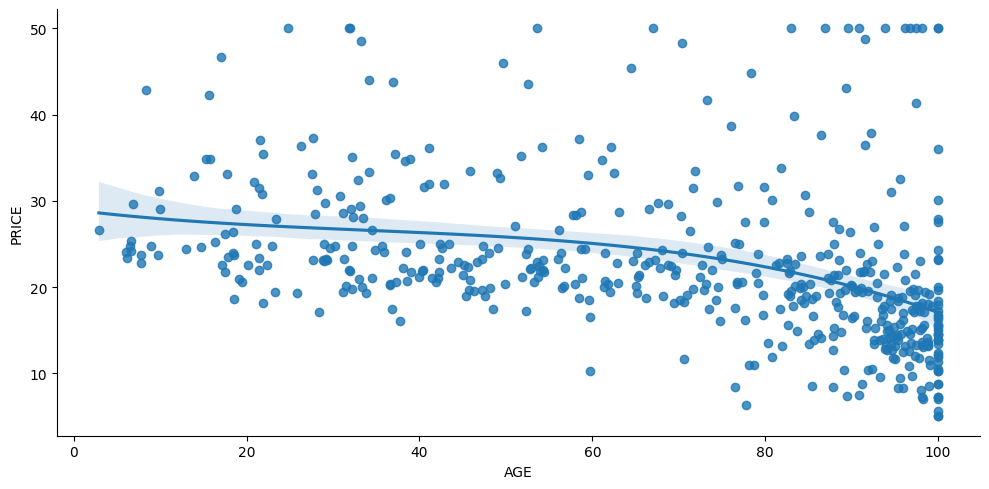

In [12]:
# Visualization of the relations between price and "proportion of owner-occupied units built prior to 1940"
sns.lmplot(x="AGE", y="PRICE", data=df_boston, aspect=2, order=3);

### Heatmap

We can also use corr function from Pandas and heatmap function from Seaborn for studying the variables relationship, plotting a diagonal correlation matrix.

<Axes: >

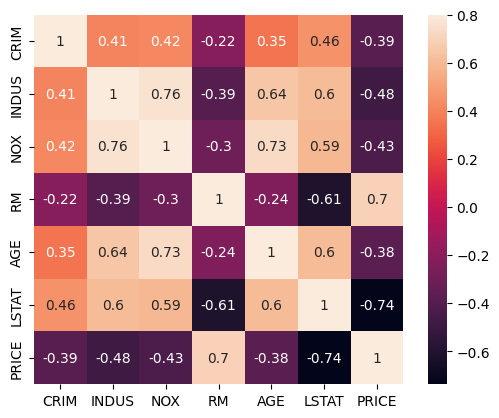

In [13]:
features2 = ['CRIM', 'INDUS', 'NOX', 'RM', 'AGE', 'LSTAT', 'PRICE'] # To plot just 7 of the 13 variables: PRICE, LSTAT, AGE, RM, NOX, INDUS, CRIM.
df_boston2 = df_boston[features2]
corrmat = df_boston2.corr()
# Draw the heatmap using seaborn
sns.heatmap(corrmat, vmax=.8, square=True, annot=True)

The correlation coefficient ranges from -1 to 1. If the value is close to 1, it means that there is a strong positive correlation between the two variables. When it is close to -1, the variables have a strong negative correlation.

### Scatter plot matrix

Let's explore multiple variables relationships using a scatter plot matrix. The scatter plot is a grid of plots of multiple varaibles one against the other, showing the pairwise relationship of each variable to the others.

For the sake of visualization, we choose 3 from the set of 13 variables:

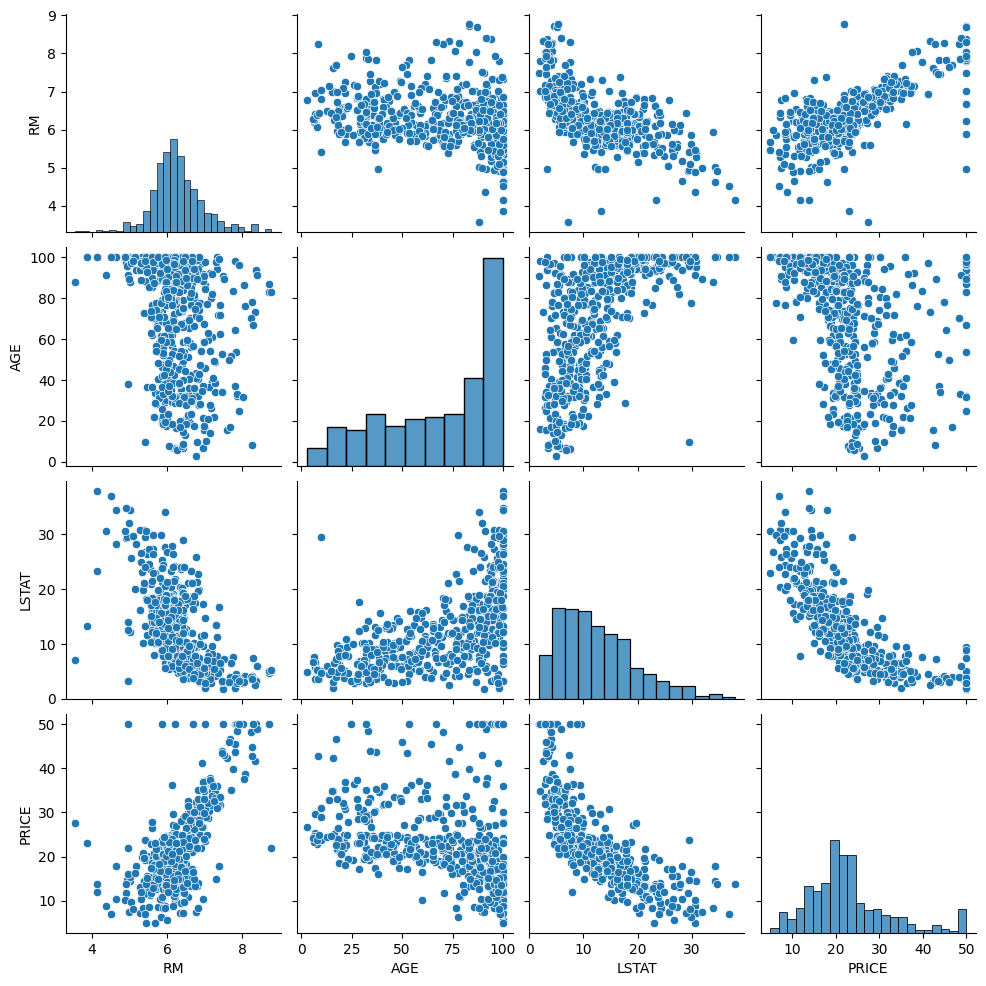

In [14]:
features3 = ['RM','AGE','LSTAT', 'PRICE'] 
df_boston3 = df_boston[features3]
sns.pairplot(df_boston3) # Plot pairwise relationships in the dataset

We can visually analyze the pairwise relationships in the scatter plots. The diagonal axe contains a plot to show the univariate distribution of the data for the variable in that column.

You can create the same scatter plot matrix using the scatter_matrix method in pandas.tools.plotting:

array([[<Axes: xlabel='RM', ylabel='RM'>,
        <Axes: xlabel='AGE', ylabel='RM'>,
        <Axes: xlabel='LSTAT', ylabel='RM'>,
        <Axes: xlabel='PRICE', ylabel='RM'>],
       [<Axes: xlabel='RM', ylabel='AGE'>,
        <Axes: xlabel='AGE', ylabel='AGE'>,
        <Axes: xlabel='LSTAT', ylabel='AGE'>,
        <Axes: xlabel='PRICE', ylabel='AGE'>],
       [<Axes: xlabel='RM', ylabel='LSTAT'>,
        <Axes: xlabel='AGE', ylabel='LSTAT'>,
        <Axes: xlabel='LSTAT', ylabel='LSTAT'>,
        <Axes: xlabel='PRICE', ylabel='LSTAT'>],
       [<Axes: xlabel='RM', ylabel='PRICE'>,
        <Axes: xlabel='AGE', ylabel='PRICE'>,
        <Axes: xlabel='LSTAT', ylabel='PRICE'>,
        <Axes: xlabel='PRICE', ylabel='PRICE'>]], dtype=object)

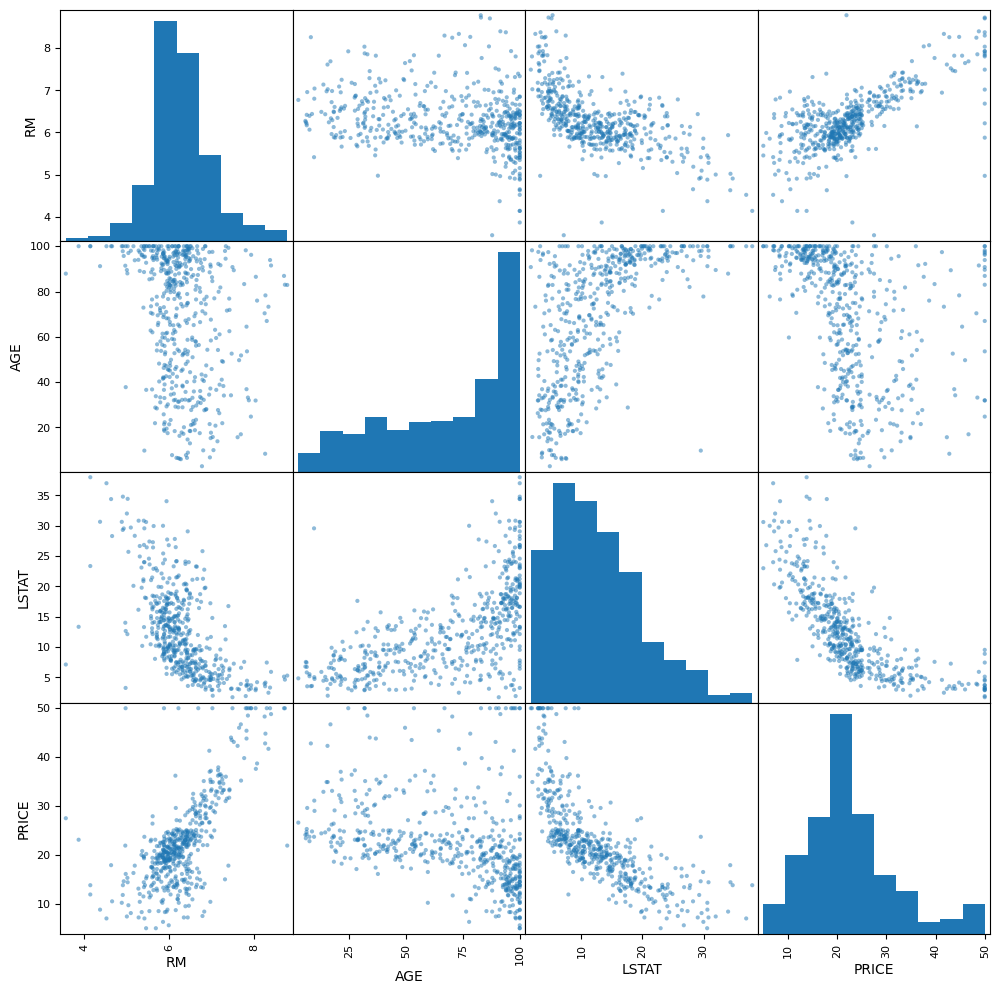

In [15]:
pd.plotting.scatter_matrix(df_boston3, figsize=(12.0,12.0))  

**Plots for the fitting evaluation:**

We can often learn a lot about how well our model did by analyzing the predictions and residuals with two interesting plots: 
- An scatter plot of the observed values $y$ versus the predicted value $\hat y$ 
- An scatter plot residuals $y_i - \hat y_i$ vs. $\hat y_i$.

In both cases we can add a line to show which would be the perfect result. 

Text(0, 0.5, 'Predicted price ($1000s)')

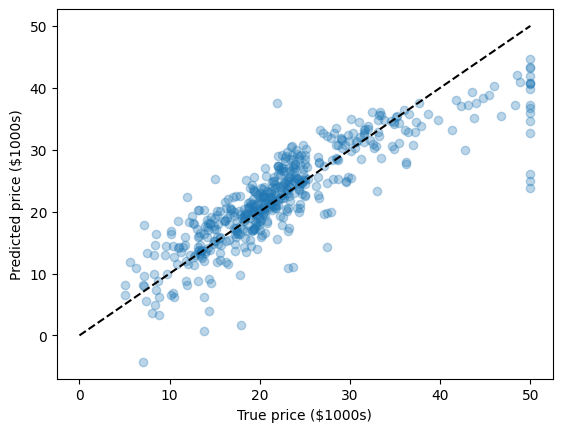

In [16]:
from sklearn.linear_model import LinearRegression

# Assuming your DataFrame is named 'df_boston'
X = df_boston.drop(['PRICE', 'MEDV'], axis=1)  # Select features (all columns except 'PRICE')
y = df_boston['PRICE']  # Target variable

reg = LinearRegression() # Create the Linear Regression estimator
reg.fit(X, y) # Fitting with all the features
y_pred = reg.predict(X) # Perform prediction of all the data

# Visualization of target and predicted responses of the boston data:
plt.scatter(y, y_pred, alpha=0.3)
plt.plot([0, 50], [0, 50], '--k')
plt.axis('tight')
plt.xlabel('True price ($1000s)')
plt.ylabel('Predicted price ($1000s)')

Text(0, 0.5, '$y - \\hat y$')

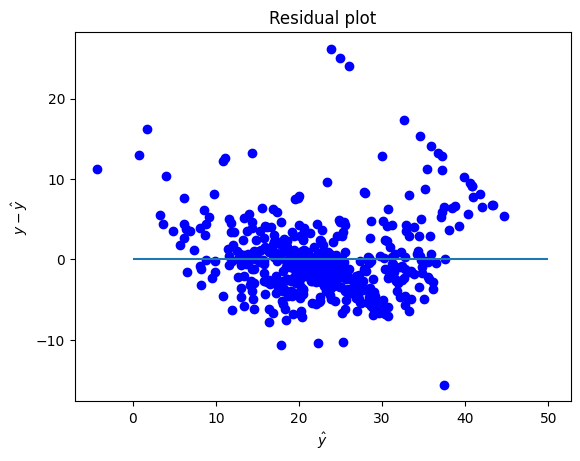

In [17]:
x_plot = plt.scatter(y_pred, (y-y_pred), c='b')
plt.hlines(y=0, xmin= 0, xmax=50)
plt.title('Residual plot')
plt.xlabel('$\hat y$')
plt.ylabel('$y - \hat y$')

Intuitively, if the model is good, then a plot of the residuals ($y_i - \hat y_i$) against the fitted values ($\hat y_i$) should look like noise (i.e., there shouldn't be any visible patterns).

<div class="alert alert-success" style = "border-radius:10px;border-width:3px;border-color:darkgreen;font-family:Verdana,sans-serif;font-size:16px;">

**EXERCISE 2** Diabetes <p>

The diabetes dataset (from scikit-learn) consists of 10 physiological variables (age, sex, weight, blood pressure) measure on 442 patients, and an indication of disease progression after one year.<p>

We will divide in training and testing sets and evaluate the prediction (using sklearn) with a simple and a multiple regression model.<p>

Fill the gaps of the exercise.

</div>

In [18]:
from sklearn import datasets
diabetes = datasets.load_diabetes()
X,y = diabetes.data, diabetes.target
feature_names = diabetes.feature_names
print(X.shape, y.shape)
print(feature_names)

(442, 10) (442,)
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


First visualize the data. Plot a histogram of the target variable.

Text(0.5, 1.0, 'Distribution of Median House Prices in Boston')

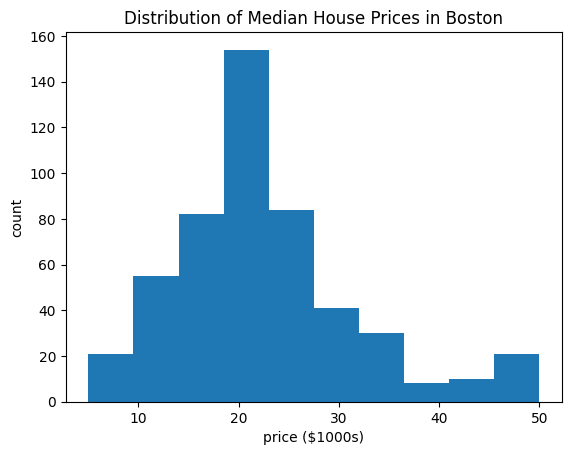

In [19]:
# Your code here
plt.hist(df_boston.PRICE) 
plt.xlabel('price ($1000s)')
plt.ylabel('count')
plt.title('Distribution of Median House Prices in Boston')

In [20]:
df_boston.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV', 'PRICE'],
      dtype='object')

Divide in training and testing sets

In [21]:
from sklearn.model_selection import train_test_split

X = df_boston[['LSTAT']]
y = df_boston['PRICE']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

For the simple model, first choose one of the dimensions of the data. Try some plots to identify possible linear relationships between the predictor and target variables. Pick one variable for your first model.

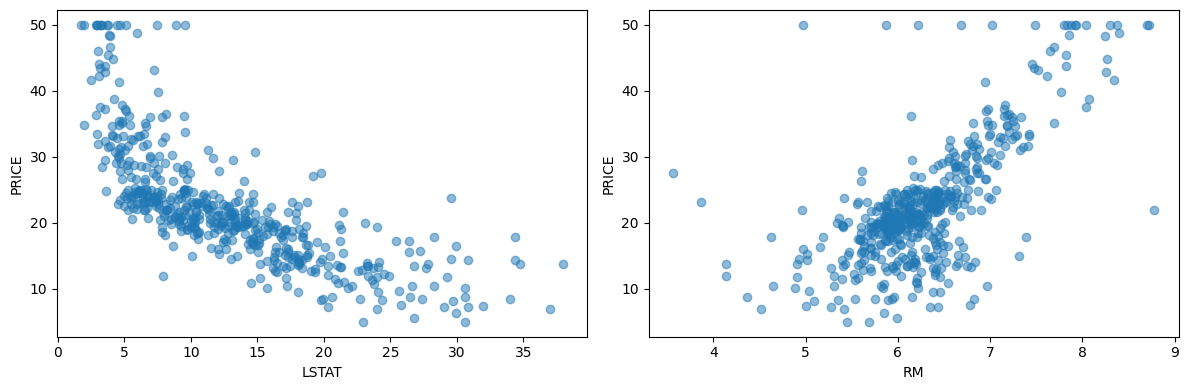

In [22]:
import matplotlib.pyplot as plt

# Quick exploration of two strong candidates: LSTAT and RM
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(df_boston['LSTAT'], df_boston['PRICE'], alpha=0.5)
axes[0].set_xlabel('LSTAT')
axes[0].set_ylabel('PRICE')
axes[1].scatter(df_boston['RM'], df_boston['PRICE'], alpha=0.5)
axes[1].set_xlabel('RM')
axes[1].set_ylabel('PRICE')
plt.tight_layout()
plt.show()

# Based on these plots, LSTAT shows a reasonably linear negative relationship. We'll pick LSTAT.

Visualize the data using scatter plot (plt.scatter):

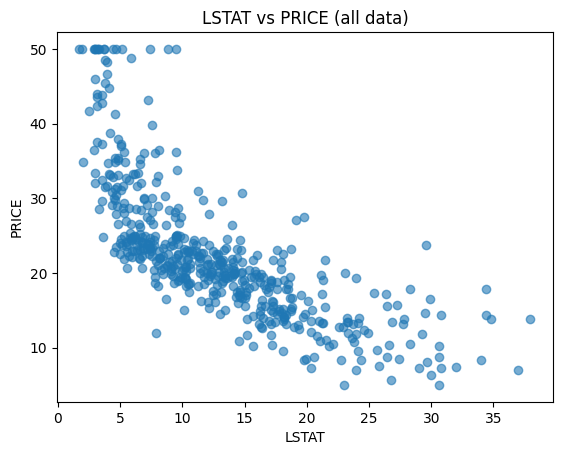

In [23]:
plt.scatter(df_boston['LSTAT'], df_boston['PRICE'], alpha=0.6)
plt.xlabel('LSTAT')
plt.ylabel('PRICE')
plt.title('LSTAT vs PRICE (all data)')
plt.show()

Visualize the data using scatter plot (plt.scatter) and two different colors for train and test data:

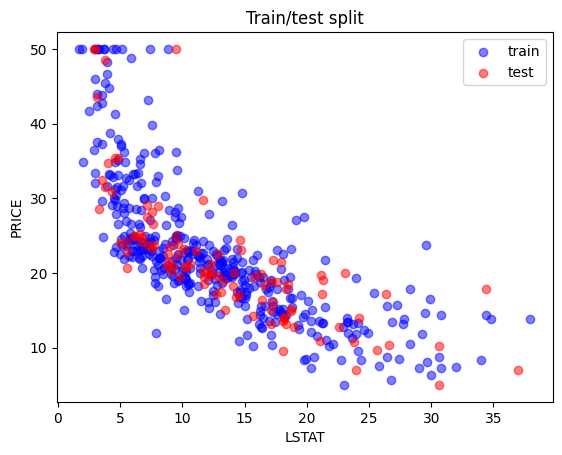

In [24]:
plt.scatter(X_train, y_train, color='blue', alpha=0.5, label='train')
plt.scatter(X_test, y_test, color='red', alpha=0.5, label='test')
plt.xlabel('LSTAT')
plt.ylabel('PRICE')
plt.legend()
plt.title('Train/test split')
plt.show()

Train and evaluate the score of the test set.

In [25]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f"Train R²: {train_score:.4f}")
print(f"Test  R²: {test_score:.4f}")

Train R²: 0.5423
Test  R²: 0.5429


Calculate the Mean Squared Error on the train and test set:

In [26]:
from sklearn.metrics import mean_squared_error

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print(f"Train MSE: {mse_train:.2f}")
print(f"Test  MSE: {mse_test:.2f}")

Train MSE: 39.76
Test  MSE: 33.52


Visualize the predicted line together with a scatter plot of the training set.

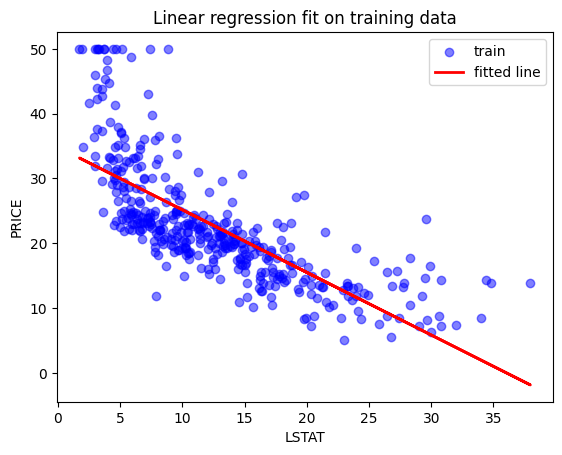

In [27]:
plt.scatter(X_train, y_train, color='blue', alpha=0.5, label='train')
plt.plot(X_train, model.predict(X_train), color='red', linewidth=2, label='fitted line')
plt.xlabel('LSTAT')
plt.ylabel('PRICE')
plt.legend()
plt.title('Linear regression fit on training data')
plt.show()

Visualize the predicted line together with a scatter plot of the training set.

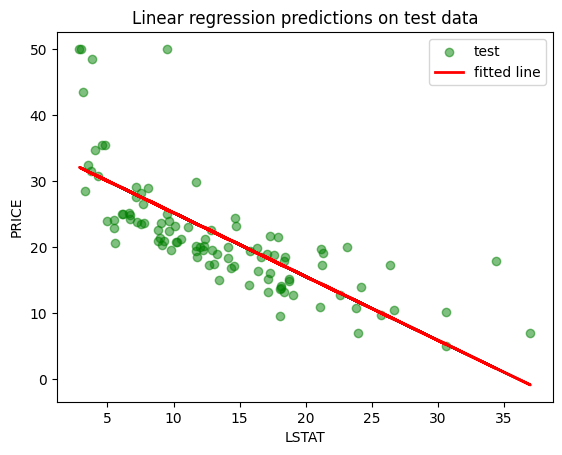

In [28]:
plt.scatter(X_test, y_test, color='green', alpha=0.5, label='test')
plt.plot(X_test, model.predict(X_test), color='red', linewidth=2, label='fitted line')
plt.xlabel('LSTAT')
plt.ylabel('PRICE')
plt.legend()
plt.title('Linear regression predictions on test data')
plt.show()

For multiple regression model divide in training and testing sets and evaluate the prediction (sklearn)

In [29]:
# Define all available features (excluding the target variable PRICE and the duplicate MEDV)
feature_cols = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
X_multi = df_boston[feature_cols]
y_multi = df_boston['PRICE']

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)

train_score_m = model_multi.score(X_train_m, y_train_m)
test_score_m = model_multi.score(X_test_m, y_test_m)

print(f"Multiple regression - Train R²: {train_score_m:.4f}")
print(f"Multiple regression - Test  R²: {test_score_m:.4f}")

Multiple regression - Train R²: 0.7509
Multiple regression - Test  R²: 0.6688


Is the score improving using all 10 variables?

In [30]:
print(f"Simple model (LSTAT only) test R²: {test_score:.4f}")
print(f"Multiple model (all features) test R²: {test_score_m:.4f}")

if test_score_m > test_score:
    print("Yes, using more variables improves the test R² score.")
else:
    print("No, the score did not improve.")

Simple model (LSTAT only) test R²: 0.5429
Multiple model (all features) test R²: 0.6688
Yes, using more variables improves the test R² score.


<div class="alert alert-success" style = "border-radius:10px;border-width:3px;border-color:darkgreen;font-family:Verdana,sans-serif;font-size:16px;">

**Exercice 3: Macroeconomic Dataset**<p>
    
In the following example we will use the Longley dataset of US macroeconomic data from the R datasets website. We want to explore the relationships between the Total Derived Employment ('Employed') and the other variables.

<ul>
<li>Is there a linear relationship between the Gross National Product ('GNP') and the Total Derived Employment ('Employed')?</li>
<li>Is there a linear relationship between the population and the Total Derived Employment ('Employed')?</li>
<li>Is there a linear relationship between the armed forces and the unemployed?</li>
<li>Can you see any non-linear effects between the armed forces and the unemployed?</li>
<li>Try to use higher order models to the fitting of GNP with Population.</li>
</ul>
    
</div>

In [31]:
# Cell 1: Import necessary libraries 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline


In [32]:
import pandas as pd
# Read data
df = pd.read_csv('http://vincentarelbundock.github.io/Rdatasets/csv/datasets/longley.csv', index_col=0)
df.head()

,GNP.deflator,GNP,Unemployed,Armed.Forces,Population,Year,Employed
rownames,,,,,,,
1947,83.0,234.289,235.6,159.0,107.608,1947,60.323
1948,88.5,259.426,232.5,145.6,108.632,1948,61.122
1949,88.2,258.054,368.2,161.6,109.773,1949,60.171
1950,89.5,284.599,335.1,165.0,110.929,1950,61.187
1951,96.2,328.975,209.9,309.9,112.075,1951,63.221


In [33]:
df.columns

Index(['GNP.deflator', 'GNP', 'Unemployed', 'Armed.Forces', 'Population',
       'Year', 'Employed'],
      dtype='object')

Is there a linear relationship between the Gross National Product ('GNP') and the Total Derived Employment ('Employed')?

Pearson correlation: 0.984 (p-value: 0.0000)
R² = 0.967


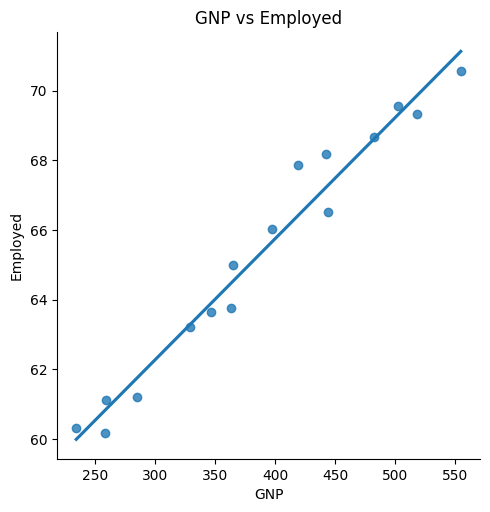

In [34]:
# Scatter plot with regression line
sns.lmplot(x='GNP', y='Employed', data=df, ci=None)
plt.title('GNP vs Employed')

# Compute Pearson correlation
corr, p_value = pearsonr(df['GNP'], df['Employed'])
print(f"Pearson correlation: {corr:.3f} (p-value: {p_value:.4f})")

# Fit linear regression and show R²
X = df[['GNP']]
y = df['Employed']
model = LinearRegression().fit(X, y)
print(f"R² = {model.score(X, y):.3f}")

Is there a linear relationship between the population and the Total Derived Employment ('Employed')?

Pearson correlation: 0.960 (p-value: 0.0000)
R² = 0.922


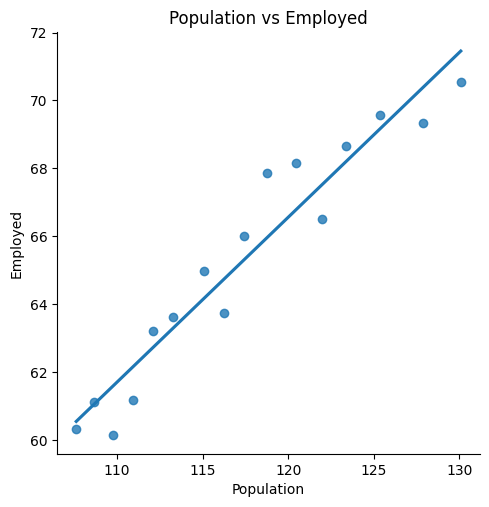

In [35]:
# Scatter plot with regression line
sns.lmplot(x='Population', y='Employed', data=df, ci=None)
plt.title('Population vs Employed')

# Compute Pearson correlation
corr, p_value = pearsonr(df['Population'], df['Employed'])
print(f"Pearson correlation: {corr:.3f} (p-value: {p_value:.4f})")

# Fit linear regression and show R²
X = df[['Population']]
y = df['Employed']
model = LinearRegression().fit(X, y)
print(f"R² = {model.score(X, y):.3f}")

Is there a linear relationship between the armed forces and the unemployed?

Pearson correlation: -0.177 (p-value: 0.5109)
R² = 0.031


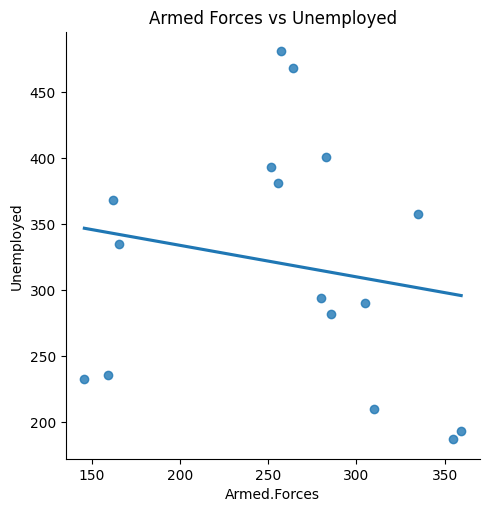

In [36]:
# Scatter plot with regression line
sns.lmplot(x='Armed.Forces', y='Unemployed', data=df, ci=None)
plt.title('Armed Forces vs Unemployed')

# Compute Pearson correlation
corr, p_value = pearsonr(df['Armed.Forces'], df['Unemployed'])
print(f"Pearson correlation: {corr:.3f} (p-value: {p_value:.4f})")

# Fit linear regression and show R²
X = df[['Armed.Forces']]
y = df['Unemployed']
model = LinearRegression().fit(X, y)
print(f"R² = {model.score(X, y):.3f}")

Can you see any non-linear effects between the armed forces and the unemployed?

Linear R² : 0.031
Quadratic R²: 0.526
Quadratic model explains notably more variance – possible non‑linearity.


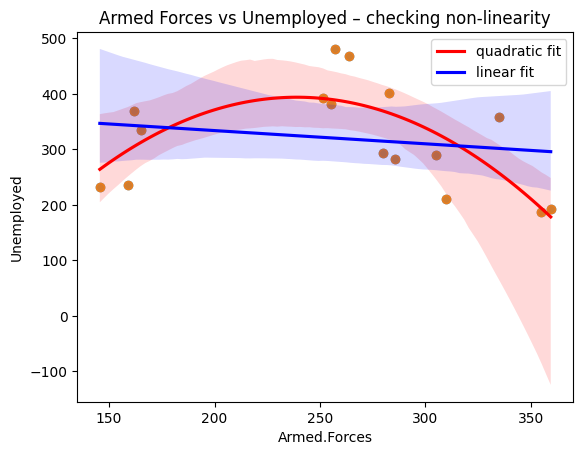

In [37]:
# Plot with a lowess smoother (or polynomial fit) to detect curvature
sns.scatterplot(x='Armed.Forces', y='Unemployed', data=df)
sns.regplot(x='Armed.Forces', y='Unemployed', data=df, order=2, line_kws={'color':'red', 'label':'quadratic fit'})
sns.regplot(x='Armed.Forces', y='Unemployed', data=df, order=1, line_kws={'color':'blue', 'label':'linear fit'})
plt.legend()
plt.title('Armed Forces vs Unemployed – checking non‑linearity')

# Compare linear and quadratic R²
X = df[['Armed.Forces']]
y = df['Unemployed']

linear = LinearRegression().fit(X, y)
r2_linear = linear.score(X, y)

poly = make_pipeline(PolynomialFeatures(2), LinearRegression())
poly.fit(X, y)
r2_quad = poly.score(X, y)

print(f"Linear R² : {r2_linear:.3f}")
print(f"Quadratic R²: {r2_quad:.3f}")
if r2_quad > r2_linear + 0.05:   # arbitrary threshold
    print("Quadratic model explains notably more variance – possible non‑linearity.")
else:
    print("Quadratic fit does not improve much – relationship appears roughly linear.")

<div class="alert alert-success" style = "border-radius:10px;border-width:3px;border-color:darkgreen;font-family:Verdana,sans-serif;font-size:16px;">

**EXERCISE 4: Advertising dataset**<p>


In the following example we will use the [advertising dataset](https://www.kaggle.com/purbar/advertising-data/data)which consists of the sales of products and their advertising budget in three different media TV, radio, newspaper.<p>
<ul>
    <li>Is there a linear relationship between the sales of products and the advertising budget in TV, radio or newspapers?</li>
    <li>Train a simple linear model for each variable to predict sales</li>
    <li>Train a multiple linear model to predict sales</li>
    <li>Compare the different models. Which one's performed best?</li>
</ul>

Dataset from the book: "An Introduction to Statistical Learning with Applications in R”. Gareth James, Daniela Witten, Trevor Hastie and Robert Tibshirani.<p>


</div>

In [38]:
# Read data
df4 = pd.read_csv('../data/Advertising.csv')
df4.head(4)

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5


In [39]:
df4.columns

Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [40]:
# Drop the redundant index column 
if 'Unnamed: 0' in df4.columns:
    df4 = df4.drop(columns=['Unnamed: 0'])

df4.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [41]:
corr = df4.corr()
print("Correlation with Sales:")
print(corr['Sales'].sort_values(ascending=False))

Correlation with Sales:
Sales        1.000000
TV           0.782224
Radio        0.576223
Newspaper    0.228299
Name: Sales, dtype: float64


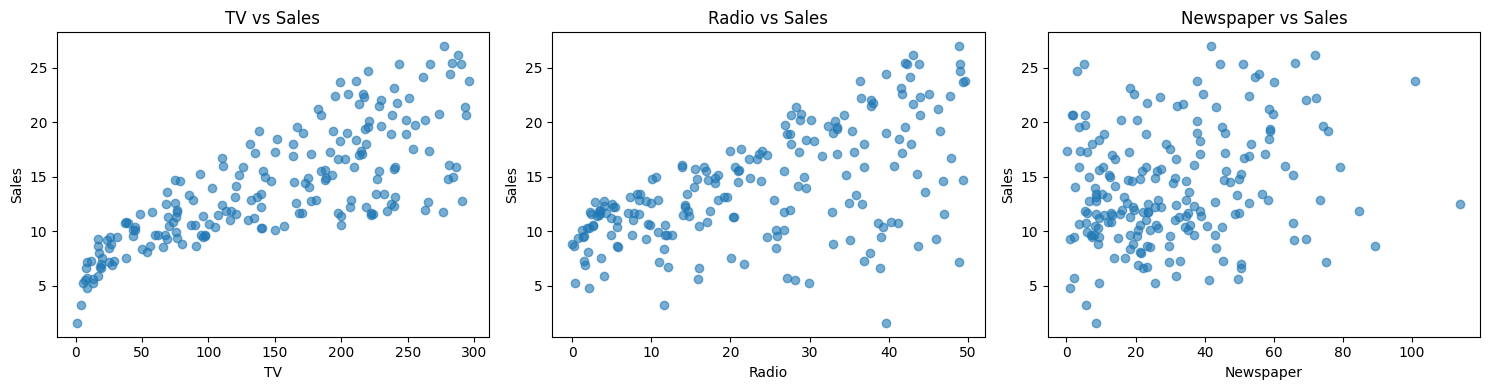

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(['TV', 'Radio', 'Newspaper']):
    axes[i].scatter(df4[col], df4['Sales'], alpha=0.6)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Sales')
    axes[i].set_title(f'{col} vs Sales')
plt.tight_layout()
plt.show()

In [43]:
X = df4[['TV', 'Radio', 'Newspaper']]   # predictors
y = df4['Sales']                         # target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
from sklearn.metrics import r2_score, mean_squared_error
# Store results
results = []

for feature in ['TV', 'Radio', 'Newspaper']:
    # Prepare single-feature data
    X_train_single = X_train[[feature]]
    X_test_single = X_test[[feature]]
    
    # Train model
    model = LinearRegression()
    model.fit(X_train_single, y_train)
    
    # Predict on test
    y_pred = model.predict(X_test_single)
    
    # Metrics
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    
    # Store
    results.append({
        'Model': f'Simple ({feature})',
        'R²': r2,
        'MSE': mse,
        'Coefficient': model.coef_[0],
        'Intercept': model.intercept_
    })
    
    print(f"\nSimple model using {feature}:")
    print(f"  Coefficient: {model.coef_[0]:.3f}")
    print(f"  Intercept: {model.intercept_:.3f}")
    print(f"  Test R²: {r2:.4f}")
    print(f"  Test MSE: {mse:.4f}")


Simple model using TV:
  Coefficient: 0.047
  Intercept: 7.120
  Test R²: 0.6767
  Test MSE: 10.2047

Simple model using Radio:
  Coefficient: 0.204
  Intercept: 9.424
  Test R²: 0.2634
  Test MSE: 23.2488

Simple model using Newspaper:
  Coefficient: 0.060
  Intercept: 12.311
  Test R²: 0.0299
  Test MSE: 30.6207


In [46]:
# Train on all features
multi_model = LinearRegression()
multi_model.fit(X_train, y_train)

# Predict on test
y_pred_multi = multi_model.predict(X_test)

# Metrics
r2_multi = r2_score(y_test, y_pred_multi)
mse_multi = mean_squared_error(y_test, y_pred_multi)

# Store
results.append({
    'Model': 'Multiple (all)',
    'R²': r2_multi,
    'MSE': mse_multi,
    'Coefficient': multi_model.coef_,
    'Intercept': multi_model.intercept_
})

print("\nMultiple linear regression (TV + Radio + Newspaper):")
print(f"  Coefficients: TV={multi_model.coef_[0]:.3f}, Radio={multi_model.coef_[1]:.3f}, Newspaper={multi_model.coef_[2]:.3f}")
print(f"  Intercept: {multi_model.intercept_:.3f}")
print(f"  Test R²: {r2_multi:.4f}")
print(f"  Test MSE: {mse_multi:.4f}")


Multiple linear regression (TV + Radio + Newspaper):
  Coefficients: TV=0.045, Radio=0.189, Newspaper=0.003
  Intercept: 2.979
  Test R²: 0.8994
  Test MSE: 3.1741


In [47]:
# Create a comparison DataFrame
comparison = pd.DataFrame(results)
comparison

,Model,R²,MSE,Coefficient,Intercept
0,Simple (TV),0.676695,10.204654,0.04653,7.119638
1,Simple (Radio),0.263431,23.248767,0.204407,9.424066
2,Simple (Newspaper),0.029872,30.620734,0.059757,12.310548
3,Multiple (all),0.899438,3.174097,"[0.044729517468716326, 0.18919505423437652, 0....",2.979067


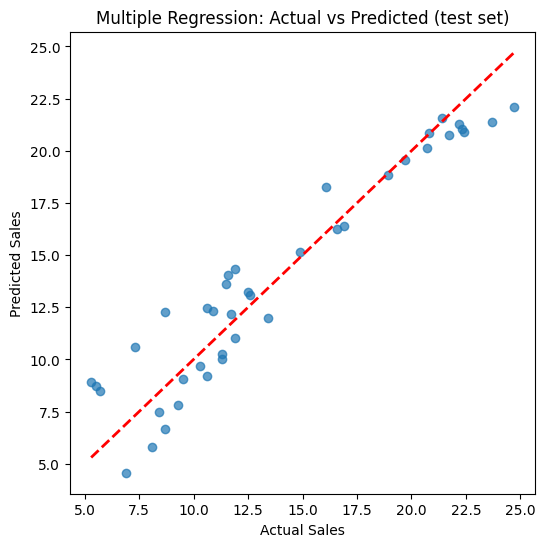

In [48]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_multi, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Multiple Regression: Actual vs Predicted (test set)')
plt.show()